# Code Lab 7 - Easy OCR

<img src="https://github.com/JaidedAI/EasyOCR/raw/master/examples/easyocr_framework.jpeg">

Этот ноутбук демонстрирует все возможности оптического распознавания символов (OCR) с использованием библиотеки EasyOCR. Мы рассмотрим различные сценарии использования, визуализацию результатов и практические примеры.

## План работы:
- Распознавание текста на изображениях (русский + английский)
- Визуализация bounding boxes
- Пакетная обработка
- Работа с разными типами изображений
- Экспорт результатов

## 1. Установка зависимостей

Выполните установку необходимых библиотек:

In [11]:
! pip install easyocr 

^C


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\alexm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2. Импорт библиотек

In [1]:
import os
import sys
import time
import json
from pathlib import Path
from datetime import datetime
from typing import List, Dict, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import easyocr

# Настройка отображения matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 3. Инициализация OCR

Создадим класс для работы с OCR с расширенными возможностями:

In [3]:
class EasyOCRDemo:
    """Класс для демонстрации возможностей OCR"""
    
    def __init__(self, languages: List[str] = ['ru', 'en'], gpu: bool = False):
        """
        Инициализация OCR-читателя
        
        Args:
            languages: Список языков для распознавания
            gpu: Использовать GPU
        """
        print(f"Инициализация OCR с языками: {languages}")
        print(f"Режим: {'GPU' if gpu else 'CPU'}")
        
        try:
            self.reader = easyocr.Reader(languages, gpu=gpu)
            self.languages = languages
            print("OCR успешно инициализирован")
        except Exception as e:
            print(f"Ошибка: {e}")
            raise
    
    def recognize(self, image_path: str, 
                 detail: int = 1,
                 paragraph: bool = False) -> List:
        """
        Распознавание текста на изображении
        """
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Файл не найден: {image_path}")
        
        print(f"\n📄 Анализ: {os.path.basename(image_path)}")
        start = time.time()
        
        result = self.reader.readtext(
            image_path,
            detail=detail,
            paragraph=paragraph,
            width_ths=0.7,
            height_ths=0.5
        )
        
        elapsed = time.time() - start
        print(f"✅ Готово за {elapsed:.2f} сек")
        
        return result
    
    def visualize(self, image_path: str, result: List = None,
                  show_confidence: bool = True, figsize=(15, 10)):
        """
        Визуализация результатов распознавания
        """
        if result is None:
            result = self.recognize(image_path)
        
        # Загружаем изображение
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Создаем фигуру
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # Оригинальное изображение
        ax1.imshow(img)
        ax1.set_title('Оригинальное изображение')
        ax1.axis('off')
        
        # Изображение с разметкой
        ax2.imshow(img)
        ax2.set_title(f'Распознано объектов: {len(result)}')
        
        # Цвета для разных уровней уверенности
        colors = {'high': 'green', 'medium': 'orange', 'low': 'red'}
        
        for detection in result:
            points = detection[0]
            text = detection[1]
            conf = detection[2]
            
            # Определяем цвет
            if conf > 0.8:
                color = colors['high']
            elif conf > 0.5:
                color = colors['medium']
            else:
                color = colors['low']
            
            # Рисуем bounding box
            polygon = plt.Polygon(points, fill=False, 
                                 edgecolor=color, linewidth=2)
            ax2.add_patch(polygon)
            
            # Добавляем текст
            x, y = points[0]
            if show_confidence:
                label = f"{text} ({conf:.2f})"
            else:
                label = text
            
            ax2.text(x, y-5, label, fontsize=8,
                    bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))
        
        ax2.axis('off')
        plt.tight_layout()
        plt.show()
        
        return result
    
    def get_text(self, result: List, min_confidence: float = 0.0) -> str:
        """
        Извлечение текста из результатов
        """
        texts = []
        for detection in result:
            if detection[2] >= min_confidence:
                texts.append(detection[1])
        return '\n'.join(texts)
    
    def save_results(self, result: List, output_path: str):
        """
        Сохранение результатов в JSON
        """
        serializable = []
        for item in result:
            serializable.append({
                'bbox': [[float(x) for x in point] for point in item[0]],
                'text': item[1],
                'confidence': float(item[2])
            })
        
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(serializable, f, ensure_ascii=False, indent=2)
        
        print(f"💾 Результаты сохранены в {output_path}")

# Создаем экземпляр
ocr = EasyOCRDemo(languages=['ru', 'en'], gpu=True)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Инициализация OCR с языками: ['ru', 'en']
Режим: GPU
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.1% CompleteOCR успешно инициализирован


## 4. Загрузка тестовых изображений


In [4]:
test_images = ['data/test1.png', 'data/test2.png', 'data/test3.png']

## 5. Базовое распознавание

Продемонстрируем распознавание текста на простом изображении:

Изображение: data/test1.png

📄 Анализ: test1.png
✅ Готово за 1.70 сек

📝 Распознанный текст:
Привет, мир!
Hello, world!


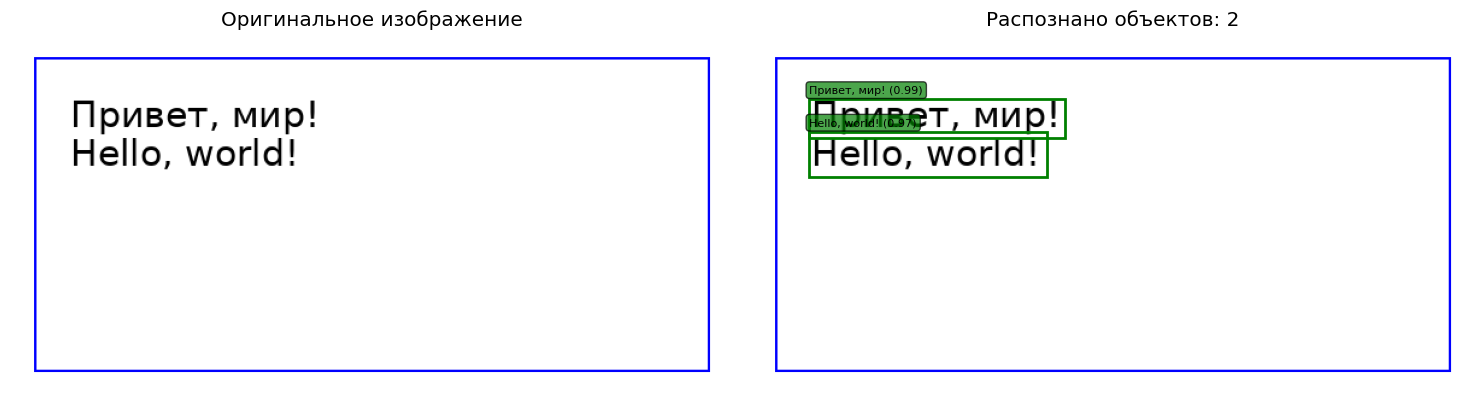

[([[np.int32(48), np.int32(54)],
   [np.int32(260), np.int32(54)],
   [np.int32(260), np.int32(86)],
   [np.int32(48), np.int32(86)]],
  'Привет, мир!',
  np.float64(0.9869981549229956)),
 ([[np.int32(48), np.int32(81)],
   [np.int32(245), np.int32(81)],
   [np.int32(245), np.int32(119)],
   [np.int32(48), np.int32(119)]],
  'Hello, world!',
  np.float64(0.9722749432753364))]

In [5]:
# Выбираем первое тестовое изображение
image_path = test_images[0]
print(f"Изображение: {image_path}")

# Выполняем распознавание
result = ocr.recognize(image_path)

# Выводим результаты
print("\n📝 Распознанный текст:")
print(ocr.get_text(result))

# Визуализируем
ocr.visualize(image_path, result)

## 6. Анализ уверенности распознавания

Посмотрим на уровень уверенности для каждого распознанного элемента:

Статистика уверенности:
  Средняя: 97.96%
  Мин: 97.23%
  Макс: 98.70%


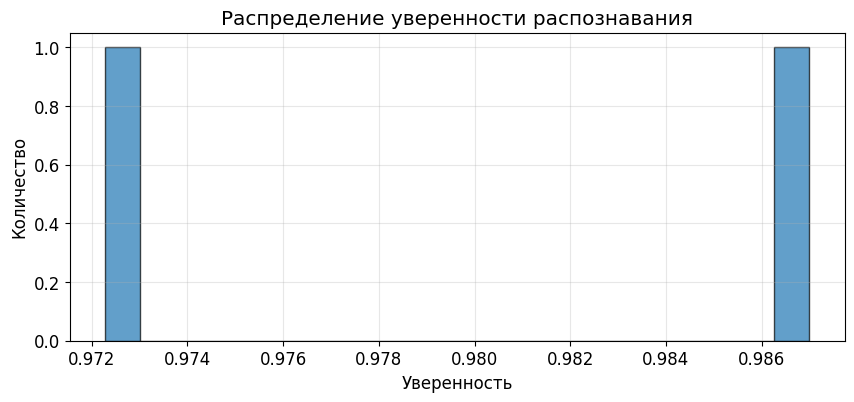


Детальные результаты:
 1. Привет, мир!                   98.70%
 2. Hello, world!                  97.23%


In [6]:
def analyze_confidence(result):
    """Анализ уверенности распознавания"""
    confidences = [item[2] for item in result]
    
    if not confidences:
        print("Нет распознанных элементов")
        return
    
    print(f"Статистика уверенности:")
    print(f"  Средняя: {np.mean(confidences):.2%}")
    print(f"  Мин: {np.min(confidences):.2%}")
    print(f"  Макс: {np.max(confidences):.2%}")
    
    # Гистограмма распределения
    plt.figure(figsize=(10, 4))
    plt.hist(confidences, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel('Уверенность')
    plt.ylabel('Количество')
    plt.title('Распределение уверенности распознавания')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Таблица результатов
    print("\nДетальные результаты:")
    for i, (bbox, text, conf) in enumerate(result, 1):
        print(f"{i:2}. {text:30} {conf:.2%}")

analyze_confidence(result)

## 7. Фильтрация по уверенности

Можно отфильтровать результаты с низкой уверенностью:

In [7]:
thresholds = [0.0, 0.5, 0.8, 0.9]

for thresh in thresholds:
    filtered_text = ocr.get_text(result, min_confidence=thresh)
    print(f"\nУверенность >= {thresh:.0%}:")
    if filtered_text:
        print(filtered_text)
    else:
        print("  Нет результатов")


Уверенность >= 0%:
Привет, мир!
Hello, world!

Уверенность >= 50%:
Привет, мир!
Hello, world!

Уверенность >= 80%:
Привет, мир!
Hello, world!

Уверенность >= 90%:
Привет, мир!
Hello, world!


## 8. Пакетная обработка

Обработаем все тестовые изображения одновременно:

In [8]:
def batch_process(image_list):
    """Пакетная обработка изображений"""
    results = {}
    
    for img_path in image_list:
        print(f"\n{'='*50}")
        result = ocr.recognize(img_path)
        results[img_path] = result
        
        # Сохраняем результаты
        json_path = img_path.replace('.png', '_result.json')
        ocr.save_results(result, json_path)
    
    return results

batch_results = batch_process(test_images)



📄 Анализ: test1.png
✅ Готово за 1.36 сек
💾 Результаты сохранены в data/test1_result.json


📄 Анализ: test2.png
✅ Готово за 1.58 сек
💾 Результаты сохранены в data/test2_result.json


📄 Анализ: test3.png
✅ Готово за 1.30 сек
💾 Результаты сохранены в data/test3_result.json


## 9. Работа с реальными изображениями

Загрузим и обработаем реальное изображение. Если у вас есть файл с изображением, укажите его путь:

Обработка: data/twd06.png

📄 Анализ: twd06.png
✅ Готово за 15.02 сек


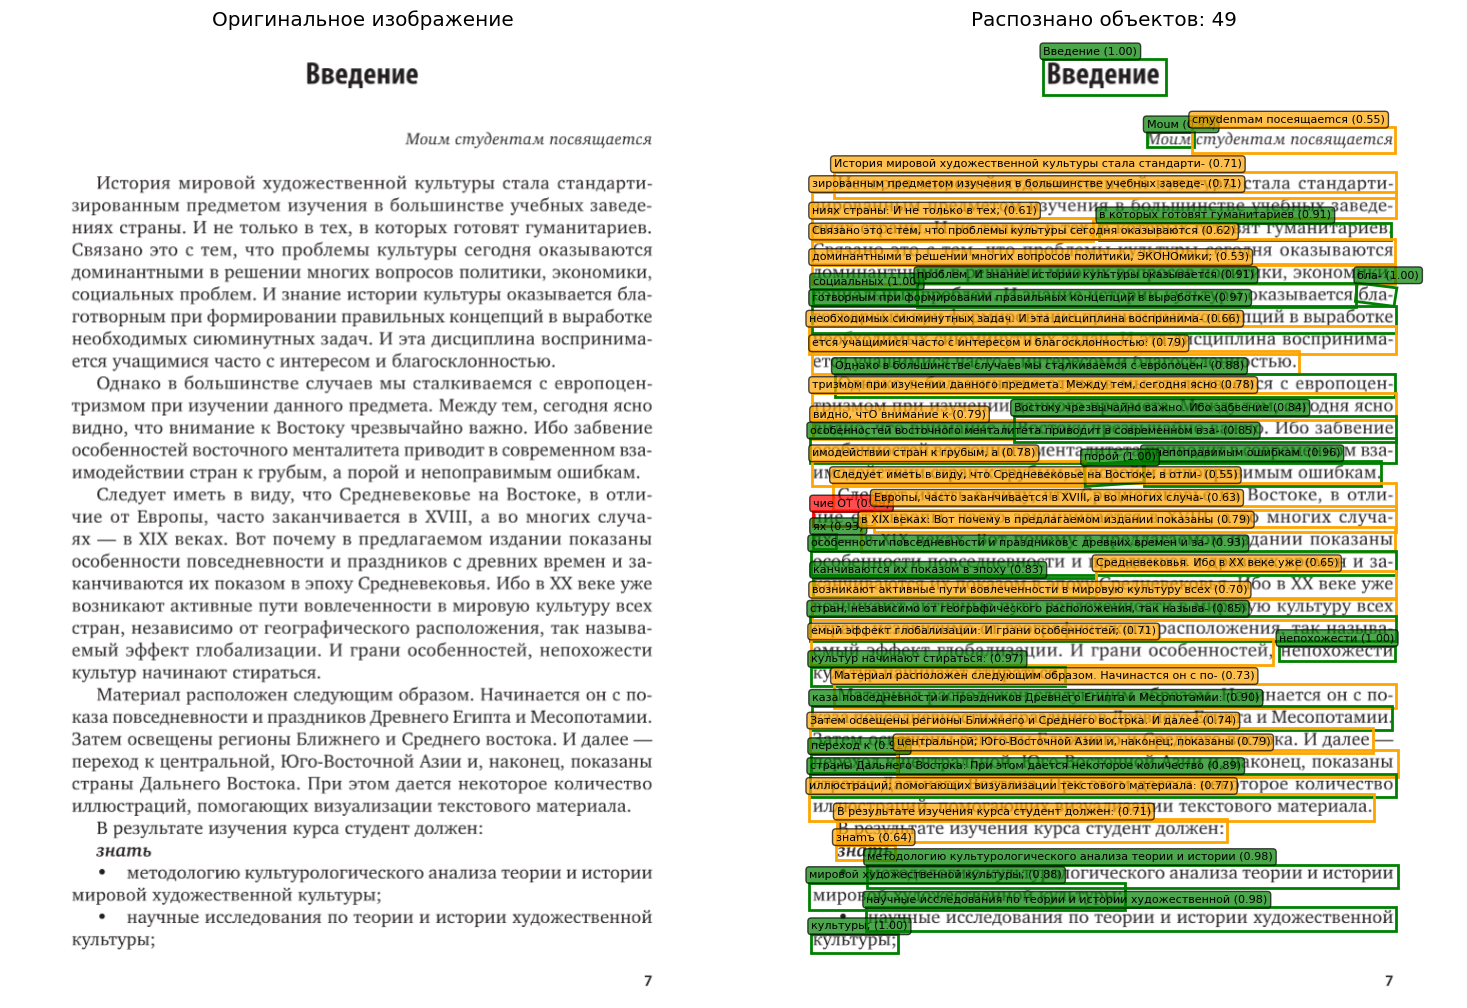


📝 Извлеченный текст:
Введение
Mouм
cmydenmaм посеящаеmся
История мировой художественной культуры стала стандарти-
зированным предметом изучения в большинстве учебных заведе-
ниях страны: И не только в тех;
в которых готовят гуманитариев
Связано это c тем, что проблемы культуры сегодня оказываются
доминантными в решении многих вопросов политики, ЭКОНОмики;
социальных
проблем. И знание истории культуры оказывается
готворным при формировании правильных концепций в выработке
необходимых сиюминутных задач. И эта дисциплина воспринима-
ется учащимися часто c интересом и благосклонностью:
Однако в большинстве случаев мы сталкиваемся c европоцен-
тризмом при изучении данного предмета. Между тем, сегодня ясно
видно, чтО внимание к
Востоку чрезвычайно важно. Ибо забвение
особенностей восточного менталитета приводит в современном вза-
имодействии стран к грубым, a
и непоправимым ошибкам.
Следует иметь в виду, что Средневековье на Востоке, в отли-
чие OT
Европы, часто заканчивается в XVIII, a во 

In [14]:
# Укажите путь к вашему изображению или используйте тестовое
real_image = 'data/twd06.png'  # Замените на свой путь

if os.path.exists(real_image):
    print(f"Обработка: {real_image}")
    result_real = ocr.recognize(real_image)
    ocr.visualize(real_image, result_real)
    
    print("\n📝 Извлеченный текст:")
    print(ocr.get_text(result_real))
else:
    print("⚠️ Файл не найден. Используйте тестовое изображение.")

## 10. Экспорт в текст

In [15]:
def export_results(result, base_name):
    """Экспорт в разные форматы"""
    
    # TXT (только текст)
    with open(f"{base_name}.txt", 'w', encoding='utf-8') as f:
        f.write(ocr.get_text(result))
    


# Экспортируем результаты для первого изображения
export_results(result, "data/ocr_results")

## 11. Анализ производительности

Измерим скорость работы OCR на разных изображениях:


📄 Анализ: test1.png
✅ Готово за 1.46 сек

📄 Анализ: test1.png
✅ Готово за 1.17 сек

📄 Анализ: test1.png
✅ Готово за 1.13 сек

📄 Анализ: test2.png
✅ Готово за 1.46 сек

📄 Анализ: test2.png
✅ Готово за 1.42 сек

📄 Анализ: test2.png
✅ Готово за 1.41 сек

📄 Анализ: test3.png
✅ Готово за 1.21 сек

📄 Анализ: test3.png
✅ Готово за 1.34 сек

📄 Анализ: test3.png
✅ Готово за 1.27 сек

📄 Анализ: twd06.png
✅ Готово за 13.85 сек

📄 Анализ: twd06.png
✅ Готово за 13.46 сек

📄 Анализ: twd06.png
✅ Готово за 14.06 сек


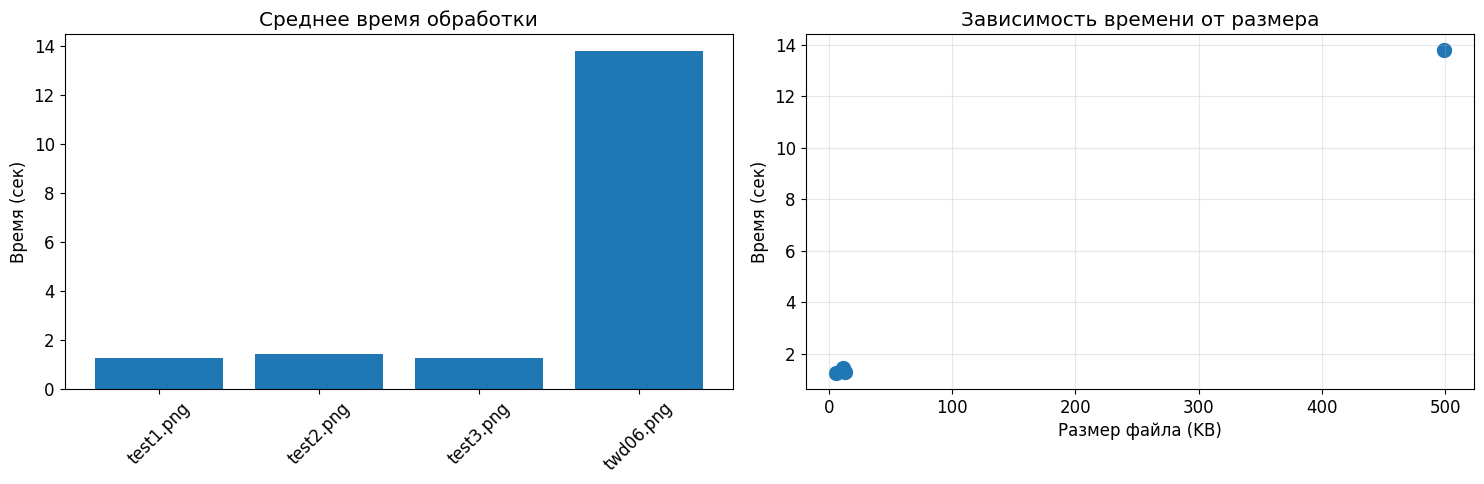


 Результаты бенчмарка:
test1.png: 1.26±0.15 сек (2 объектов)
test2.png: 1.43±0.02 сек (3 объектов)
test3.png: 1.27±0.06 сек (3 объектов)
twd06.png: 13.79±0.25 сек (49 объектов)


In [16]:
def benchmark_ocr(image_paths, iterations=3):
    """Тестирование производительности"""
    
    results = []
    
    for img_path in image_paths:
        times = []
        file_size = os.path.getsize(img_path) / 1024  # KB
        
        for i in range(iterations):
            start = time.time()
            result = ocr.recognize(img_path)
            elapsed = time.time() - start
            times.append(elapsed)
        
        results.append({
            'file': os.path.basename(img_path),
            'size_kb': file_size,
            'objects': len(result),
            'avg_time': np.mean(times),
            'std_time': np.std(times)
        })
    
    # Визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Время обработки
    files = [r['file'] for r in results]
    times = [r['avg_time'] for r in results]
    
    ax1.bar(files, times)
    ax1.set_ylabel('Время (сек)')
    ax1.set_title('Среднее время обработки')
    ax1.tick_params(axis='x', rotation=45)
    
    # Зависимость времени от размера файла
    sizes = [r['size_kb'] for r in results]
    ax2.scatter(sizes, times, s=100)
    ax2.set_xlabel('Размер файла (KB)')
    ax2.set_ylabel('Время (сек)')
    ax2.set_title('Зависимость времени от размера')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results

benchmark = benchmark_ocr(test_images + [real_image])  # Добавляем реальное изображение в тесты
print("\n Результаты бенчмарка:")
for r in benchmark:
    print(f"{r['file']}: {r['avg_time']:.2f}±{r['std_time']:.2f} сек ({r['objects']} объектов)")

## Заключение

Мы продемонстрировали основные возможности OCR:

- Распознавание текста на изображениях
- Визуализация bounding boxes
- Анализ уверенности распознавания
- Пакетная обработка
- Экспорт в различные форматы
- Интерактивный интерфейс
- Бенчмаркинг производительности

### Дополнительные возможности:
- Поддержка более 80 языков
- Работа с GPU для ускорения
- Настройка параметров распознавания
- Интеграция в веб-приложения

### Полезные ссылки:
- [Документация EasyOCR](https://www.jaided.ai/easyocr/)
